In [56]:
!pip install xgboost shap

# **Import Libraries**

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

### **Load Dataset**

In [58]:
df = pd.read_csv("/content/car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [59]:
print(df.shape)
print(df.info())

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [60]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [61]:
print(df.duplicated().sum())

2


In [62]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


## **Feature Engineering**

In [63]:
CURRENT_YEAR = 2026
df['Car_Age'] = CURRENT_YEAR - df['Year']
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [64]:
df['Brand'] = df['Car_Name'].apply(
    lambda x: str(x).split()[0].lower()
)
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift
...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10,city
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11,brio
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17,city
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9,city


### **Exploratory Data Analysis**

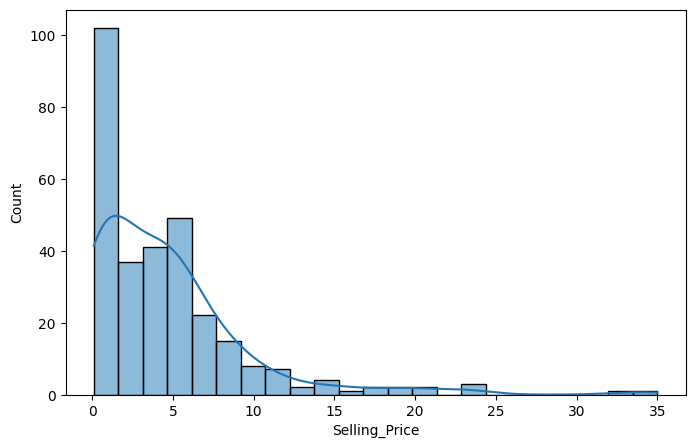

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Selling_Price'],
    kde=True
)
plt.show()

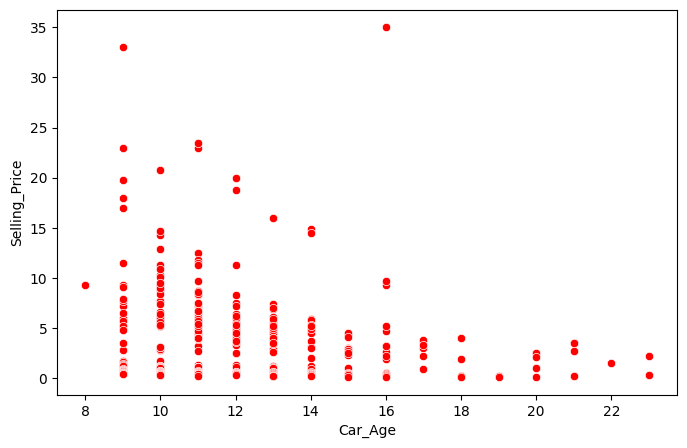

In [66]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price",
    color='red'
)
plt.show()

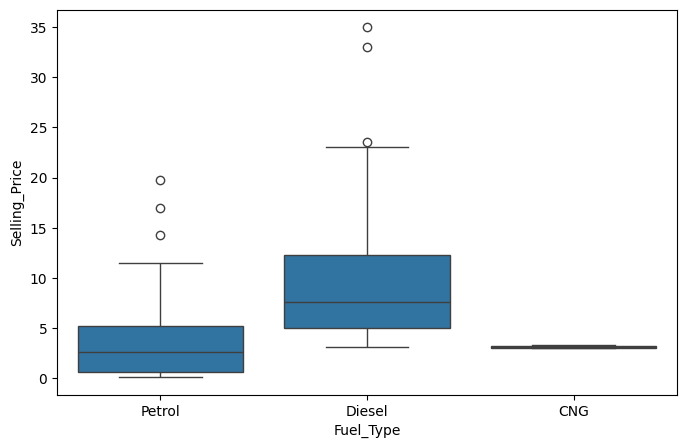

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.show()

### **Train Test Split**

In [68]:
x = df.drop(
    "Selling_Price",
    axis=1
)
y = df['Selling_Price']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=42)

In [69]:
train_temp = x_train.copy()
train_temp["Selling_Price"] = y_train

In [70]:
brand_goodwill = (
    train_temp.groupby("Brand")["Selling_Price"].mean()
)
global_mean = y_train.mean()

In [71]:
x_train["Brand_Goodwill"] = (
    x_train["Brand"]
    .map(brand_goodwill)
    .fillna(global_mean)
)

x_test["Brand_Goodwill"] = (
    x_test["Brand"]
    .map(brand_goodwill)
    .fillna(global_mean)
)

In [72]:
x_train["Condition_Score"] = (
    100
    - (x_train["Car_Age"]*2)
    - (x_train["Driven_kms"]/5000)
)

x_test["Condition_Score"] = (
    100
    - (x_test["Car_Age"]*2)
    - (x_test["Driven_kms"]/5000)
)

In [73]:
x_train["Condition_Score"] = (
    x_train["Condition_Score"]
    .clip(lower=0)
)

x_test["Condition_Score"] = (
    x_test["Condition_Score"]
    .clip(lower=0)
)

### **Vehicle Value Index**

In [74]:
x_train["VVI"] = (
    0.4 * x_train["Brand_Goodwill"]
    + 0.3 * x_train["Condition_Score"]
    + 0.3 * x_train["Present_Price"]
)

In [75]:
x_test["VVI"] = (
    0.4 * x_test["Brand_Goodwill"]
    + 0.3 * x_test["Condition_Score"]
    + 0.3 * x_test["Present_Price"]
)

In [76]:
x_train.drop(
    columns=["Car_Name","Year"],
    inplace=True
)

x_test.drop(
    columns=["Car_Name","Year"],
    inplace=True
)

In [77]:
combined = pd.concat(
    [x_train,x_test],
    axis=0
)

In [78]:
combined = pd.get_dummies(
    combined,
    columns=[
        "Fuel_Type",
        "Selling_type",
        "Transmission",
        "Brand"
    ],
    drop_first=True
)

In [79]:
x_train = combined.iloc[:len(x_train)]

x_test = combined.iloc[len(x_train):]

In [80]:
lr = LinearRegression()

lr.fit(
    x_train,
    y_train
)

predict_lr = lr.predict(
    x_test
)

### **Random Forest**

In [81]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(
    x_train,
    y_train
)

pred_rf = rf.predict(
    x_test
)

### **Gradient Boostinf**

In [82]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    x_train,
    y_train
)

pred_gb = gb.predict(
    x_test
)

### **XGBoost**

In [83]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(
    x_train,
    y_train
)

pred_xgb = xgb.predict(
    x_test
)

### **Cross Validation**

In [84]:
scores = cross_val_score(
    xgb,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(
    "Average R2:",
    scores.mean()
)

Average R2: 0.9270910814914973


In [85]:
estimators = [
    ("rf",rf),
    ("gb",gb),
    ("xgb",xgb)
]

In [86]:
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

In [87]:
stack.fit(
    x_train,
    y_train
)
pred_stack = stack.predict(
    x_test
)

### **Evaluation Model**

In [88]:
def evaluate(
    y_true,
    y_pred,
    name
):
    print("\n",name)
    print(
        "Mean Absolute Error:",
        mean_absolute_error(
            y_true,
            y_pred
        )
    )
    print(
        "Root Mean Squared Error:",
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )
    print(
        "R2:",
        r2_score(
            y_true,
            y_pred
        )
    )

### **Compare Models**

In [89]:
evaluate(
    y_test,
    predict_lr,
    "Linear Regression"
)

evaluate(
    y_test,
    pred_rf,
    "Random Forest"
)

evaluate(
    y_test,
    pred_gb,
    "Gradient Boosting"
)

evaluate(
    y_test,
    pred_xgb,
    "XGBoost"
)

evaluate(
    y_test,
    pred_stack,
    "Stacking Ensemble"
)


 Linear Regression
Mean Absolute Error: 1.4309816231761168
Root Mean Squared Error: 2.7006447723970717
R2: 0.7170136196268144

 Random Forest
Mean Absolute Error: 0.8087177777777773
Root Mean Squared Error: 1.7624764824908534
R2: 0.8794749642264921

 Gradient Boosting
Mean Absolute Error: 0.6285836840223813
Root Mean Squared Error: 1.5008764164432573
R2: 0.912598180315207

 XGBoost
Mean Absolute Error: 0.6278444722394148
Root Mean Squared Error: 1.4769142986179877
R2: 0.915366715060947

 Stacking Ensemble
Mean Absolute Error: 0.698775209857627
Root Mean Squared Error: 1.5069429026594379
R2: 0.911890202633423


In [90]:
importance = pd.DataFrame({

    "Feature":
    x_train.columns,

    "Importance":
    rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
6,VVI,0.651297
0,Present_Price,0.164750
4,Brand_Goodwill,0.145810
3,Car_Age,0.012951
38,Brand_land,0.007588
1,Driven_kms,0.005063
5,Condition_Score,0.003624
9,Selling_type_Individual,0.002140
10,Transmission_Manual,0.001607
19,Brand_city,0.000781


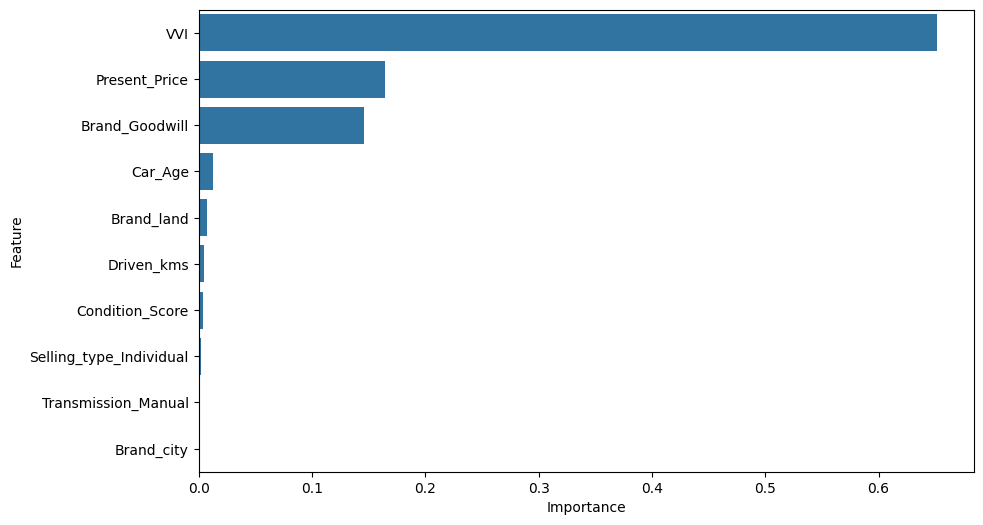

In [91]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

### **Shap Explainability**

In [92]:
import shap
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    x_test
)


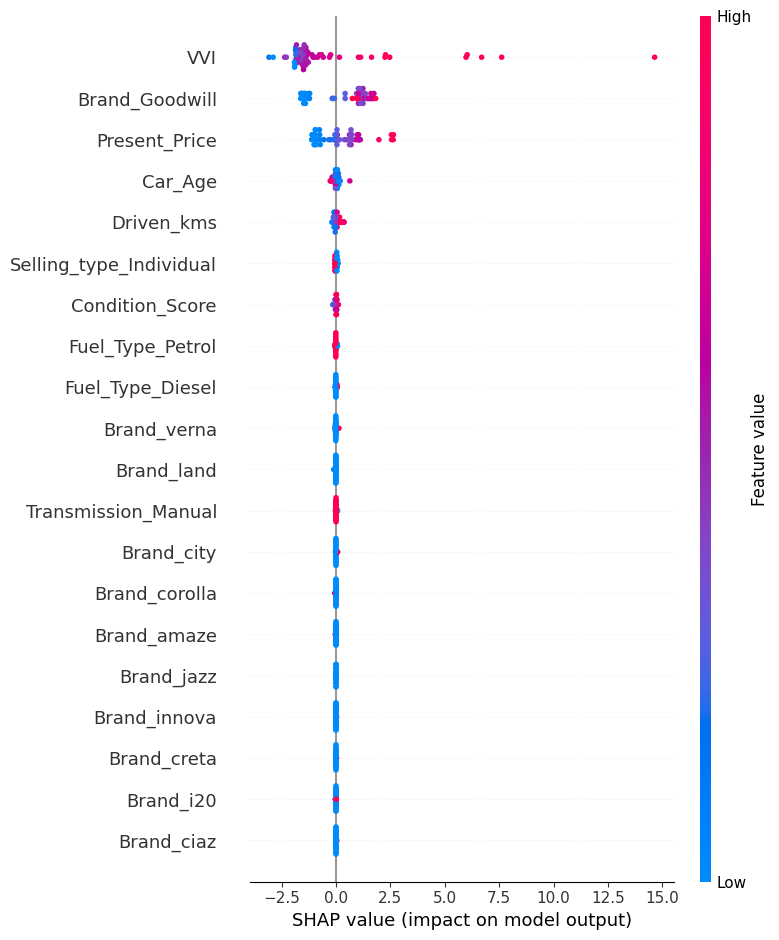

In [93]:
shap.summary_plot(
    shap_values,
    x_test
)

### **Smart Recommendation System**

In [94]:
sample = x_test.iloc[[0]]

predicted_price = stack.predict(
    sample
)[0]

print(
    "Predicted Price:",
    round(predicted_price,2),
    "Lakhs"
)
market_price = predicted_price * 1.15

Predicted Price: 9.36 Lakhs


In [95]:
if market_price > predicted_price*1.1:

    print(
        "Overpriced Vehicle"
    )
elif market_price < predicted_price*0.9:
    print(
        "Good Deal"
    )
else:
    print(
        "Fair Price"
    )

Overpriced Vehicle


In [96]:
joblib.dump(
    stack,
    "car_price_prediction_model.pkl"
)

['car_price_prediction_model.pkl']

In [97]:
import joblib

model = joblib.load("car_price_prediction_model.pkl")

print(model)

StackingRegressor(estimators=[('rf',
                               RandomForestRegressor(n_estimators=300,
                                                     random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=...
                                            importance_type=None,
                                            interac

In [98]:
!pip install streamlit

In [99]:
brand_goodwill.to_dict()

{'800': 0.35,
 'activa': 0.42500000000000004,
 'alto': 2.6166666666666667,
 'amaze': 4.175,
 'bajaj': 0.5060869565217392,
 'baleno': 5.85,
 'brio': 4.688888888888889,
 'ciaz': 7.475,
 'city': 7.2076190476190485,
 'corolla': 7.943636363636363,
 'creta': 11.25,
 'dzire': 3.45,
 'elantra': 11.45,
 'eon': 2.9,
 'ertiga': 6.58,
 'etios': 4.09375,
 'fortuner': 17.48625,
 'grand': 4.94375,
 'hero': 0.35,
 'honda': 0.478,
 'i10': 3.06,
 'i20': 4.8999999999999995,
 'ignis': 4.9,
 'innova': 12.8125,
 'jazz': 5.828571428571428,
 'ktm': 1.3833333333333335,
 'land': 35.0,
 'omni': 1.25,
 'ritz': 2.9333333333333336,
 'royal': 1.1500000000000001,
 'suzuki': 0.25,
 'swift': 5.183333333333334,
 'sx4': 3.158333333333333,
 'tvs': 0.49499999999999994,
 'um': 1.7,
 'verna': 6.350833333333334,
 'wagon': 2.875,
 'xcent': 5.075,
 'yamaha': 0.5660000000000001}

In [100]:
import joblib

joblib.dump(
    brand_goodwill,
    "brand_goodwill.pkl"
)

['brand_goodwill.pkl']

In [101]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
from datetime import datetime

# Load Model
model = joblib.load(
    "car_price_prediction_model.pkl"
)

brand_goodwill = joblib.load(
    "brand_goodwill.pkl"
)

# Title
st.title("🚗 Car Price Prediction System")

st.write(
    "Predict the resale value of a used car using Machine Learning."
)

# Inputs

present_price = st.number_input(
    "Present Price (Lakhs)",
    min_value=0.0,
    value=5.0
)

kms_driven = st.number_input(
    "Kilometers Driven",
    min_value=0,
    value=30000
)

owner = st.selectbox(
    "Number of Owners",
    [0,1,2,3]
)

year = st.selectbox(
    "Manufacturing Year",
    list(range(2005,2027))
)

fuel_type = st.selectbox(
    "Fuel Type",
    ["Petrol","Diesel","CNG"]
)

selling_type = st.selectbox(
    "Selling Type",
    ["Dealer","Individual"]
)

transmission = st.selectbox(
    "Transmission",
    ["Manual","Automatic"]
)

brand = st.selectbox(
    "Brand",
    [
        "maruti",
        "hyundai",
        "honda",
        "toyota",
        "bajaj",
        "yamaha",
        "hero",
        "tvs"
    ]
)

# Prediction Button

if st.button("Predict Price"):

    current_year = datetime.now().year

    car_age = current_year - year

    goodwill = brand_goodwill.get(
        brand,
        4.0
    )

    condition_score = (
        100
        - (car_age * 2)
        - (kms_driven / 5000)
    )

    if condition_score < 0:
        condition_score = 0

    vvi = (
        0.4 * goodwill
        + 0.3 * condition_score
        + 0.3 * present_price
    )

    data = {
        "Present_Price":[present_price],
        "Driven_kms":[kms_driven],
        "Owner":[owner],
        "Car_Age":[car_age],
        "Brand_Goodwill":[goodwill],
        "Condition_Score":[condition_score],
        "VVI":[vvi]
    }

    input_df = pd.DataFrame(data)

    prediction = model.predict(
        input_df
    )[0]

    st.success(
        f"Estimated Selling Price: ₹ {prediction:.2f} Lakhs"
    )

    if prediction > present_price:
        st.info(
            "Vehicle retains high resale value."
        )

    elif prediction < present_price*0.5:
        st.warning(
            "Vehicle has depreciated significantly."
        )

    else:
        st.info(
            "Vehicle has average resale value."
        )

Overwriting app.py


In [102]:
print(
    "Project Completed Successfully"
)

Project Completed Successfully
